# Генеративные текстовые модели — Посимвольная токенизация

В данном ноутбуке реализована посимвольная токенизация текста и обучение следующих моделей:
1. Simple RNN
2. Однослойная LSTM
3. Многослойная LSTM
4. Двунаправленная LSTM
5. Трансформер (GPT) с нуля

## 0. Настройка окружения

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from utils import (load_dataset, TextDataset, create_dataloaders,
                   train_model, generate_text, compute_perplexity,
                   plot_training_history, print_results_table)
from models import SimpleRNNModel, LSTMModel, MiniGPT

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch версия: {torch.__version__}')
print(f'CUDA доступна: {torch.cuda.is_available()}')
print(f'Устройство: {device}')

PyTorch версия: 2.8.0+cu129
CUDA доступна: True
Устройство: cuda

## 1. Загрузка и подготовка данных

In [2]:
corpus = load_dataset("medium_articles.csv", max_articles=5000, min_length=200)
print(f"Длина корпуса: {len(corpus):,} символов")
print(f"Пример текста (первые 500 символов):\n{corpus[:500]}")

[Данные] Загрузка из medium_articles.csv...
[Данные] Загружено 4865 статей, общий объём: 28,071,447 символов
Длина корпуса: 28,071,447 символов
Пример текста (первые 500 символов):
The world of data science is rapidly evolving. Machine learning algorithms are becoming more sophisticated, and the tools available to practitioners are expanding at an unprecedented rate. In this article, we will explore some of the key trends shaping the future of artificial intelligence and how they might impact various industries. From natural language processing to computer vision, the applications are virtually limitless. The democratization of AI tools means that even small companies can now leverage...

## 2. Посимвольная токенизация

In [3]:
# Построение словаря символов
chars = sorted(set(corpus))
vocab_size = len(chars)
print(f"Размер словаря (уникальные символы): {vocab_size}")

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Кодирование всего корпуса
encoded = [char_to_idx[ch] for ch in corpus]
print(f"Длина закодированной последовательности: {len(encoded):,}")
print(f"Пример кодирования: '{corpus[:20]}' -> {encoded[:20]}")

Размер словаря (уникальные символы): 2747
Длина закодированной последовательности: 28,071,447
Пример кодирования: 'The world of data ' -> [42, 680, 577, 7, 2255, 1843, 691, 576, 7, 1764, 573, 2089, 573, 7]

## 3. Создание DataLoader'ов

In [4]:
SEQ_LENGTH = 128
BATCH_SIZE = 256
EPOCHS = 10

train_loader, val_loader = create_dataloaders(encoded, SEQ_LENGTH, BATCH_SIZE)
print(f"Длина последовательности: {SEQ_LENGTH}")
print(f"Размер батча: {BATCH_SIZE}")
print(f"Количество батчей (обуч.): {len(train_loader)}")

[Данные] Обучающая выборка: 197377 примеров, валидационная: 21931 примеров
Длина последовательности: 128
Размер батча: 128
Количество батчей (обуч.): 1542

## 4. Обучение моделей

### 4.1. Simple RNN

In [5]:
model_rnn = SimpleRNNModel(vocab_size, embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.2)
history_rnn = train_model(model_rnn, train_loader, val_loader, epochs=EPOCHS,
                          device=device, lr=1e-3, model_name="char_simple_rnn")

Обучение модели: Simple RNN
Параметры: 1,156,411
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 2.0422 | Потери вал.: 1.6957 | Перплексия: 5.45
  Эпоха   2/10 | Потери обуч.: 1.7433 | Потери вал.: 1.6117 | Перплексия: 5.01
  Эпоха   3/10 | Потери обуч.: 1.6939 | Потери вал.: 1.5836 | Перплексия: 4.87
  Эпоха   4/10 | Потери обуч.: 1.6725 | Потери вал.: 1.5694 | Перплексия: 4.80
  Эпоха   5/10 | Потери обуч.: 1.6598 | Потери вал.: 1.5581 | Перплексия: 4.75
  Эпоха   6/10 | Потери обуч.: 1.6511 | Потери вал.: 1.5529 | Перплексия: 4.73
  Эпоха   7/10 | Потери обуч.: 1.6451 | Потери вал.: 1.5464 | Перплексия: 4.69
  Эпоха   8/10 | Потери обуч.: 1.6404 | Потери вал.: 1.5436 | Перплексия: 4.68
  Эпоха   9/10 | Потери обуч.: 1.6375 | Потери вал.: 1.5413 | Перплексия: 4.67
  Эпоха  10/10 | Потери обуч.: 1.6361 | Потери вал.: 1.5405 | Перплексия: 4.67
  Лучшие потери на валидации: 1.5405 (перплексия: 4.67)

### 4.2. Однослойная LSTM

In [6]:
model_lstm1 = LSTMModel(vocab_size, embed_dim=128, hidden_dim=256, num_layers=1, dropout=0.2)
history_lstm1 = train_model(model_lstm1, train_loader, val_loader, epochs=EPOCHS,
                            device=device, lr=1e-3, model_name="char_lstm_1layer")

Обучение модели: LSTM (1 слой)
Параметры: 1,452,859
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 2.2001 | Потери вал.: 1.8152 | Перплексия: 6.14
  Эпоха   2/10 | Потери обуч.: 1.7649 | Потери вал.: 1.5955 | Перплексия: 4.93
  Эпоха   3/10 | Потери обуч.: 1.6203 | Потери вал.: 1.5072 | Перплексия: 4.51
  Эпоха   4/10 | Потери обуч.: 1.5552 | Потери вал.: 1.4656 | Перплексия: 4.33
  Эпоха   5/10 | Потери обуч.: 1.5203 | Потери вал.: 1.4414 | Перплексия: 4.23
  Эпоха   6/10 | Потери обуч.: 1.4989 | Потери вал.: 1.4267 | Перплексия: 4.16
  Эпоха   7/10 | Потери обуч.: 1.4852 | Потери вал.: 1.4164 | Перплексия: 4.12
  Эпоха   8/10 | Потери обуч.: 1.4766 | Потери вал.: 1.4108 | Перплексия: 4.10
  Эпоха   9/10 | Потери обуч.: 1.4715 | Потери вал.: 1.4078 | Перплексия: 4.09
  Эпоха  10/10 | Потери обуч.: 1.4691 | Потери вал.: 1.4070 | Перплексия: 4.08
  Лучшие потери на валидации: 1.4070 (перплексия: 4.08)

### 4.3. Многослойная LSTM (3 слоя)

In [7]:
model_lstm3 = LSTMModel(vocab_size, embed_dim=128, hidden_dim=256, num_layers=3, dropout=0.3)
history_lstm3 = train_model(model_lstm3, train_loader, val_loader, epochs=EPOCHS,
                            device=device, lr=1e-3, model_name="char_lstm_3layer")

Обучение модели: LSTM (3 слоя)
Параметры: 2,505,531
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 2.6138 | Потери вал.: 1.9548 | Перплексия: 7.06
  Эпоха   2/10 | Потери обуч.: 1.8463 | Потери вал.: 1.5639 | Перплексия: 4.78
  Эпоха   3/10 | Потери обуч.: 1.6171 | Потери вал.: 1.4571 | Перплексия: 4.29
  Эпоха   4/10 | Потери обуч.: 1.5326 | Потери вал.: 1.4094 | Перплексия: 4.09
  Эпоха   5/10 | Потери обуч.: 1.4887 | Потери вал.: 1.3788 | Перплексия: 3.97
  Эпоха   6/10 | Потери обуч.: 1.4614 | Потери вал.: 1.3607 | Перплексия: 3.90
  Эпоха   7/10 | Потери обуч.: 1.4434 | Потери вал.: 1.3480 | Перплексия: 3.85
  Эпоха   8/10 | Потери обуч.: 1.4316 | Потери вал.: 1.3399 | Перплексия: 3.82
  Эпоха   9/10 | Потери обуч.: 1.4250 | Потери вал.: 1.3362 | Перплексия: 3.80
  Эпоха  10/10 | Потери обуч.: 1.4218 | Потери вал.: 1.3350 | Перплексия: 3.80
  Лучшие потери на валидации: 1.3350 (перплексия: 3.80)

### 4.4. Двунаправленная LSTM

In [8]:
model_bilstm = LSTMModel(vocab_size, embed_dim=128, hidden_dim=256, num_layers=2,
                          bidirectional=True, dropout=0.3)
history_bilstm = train_model(model_bilstm, train_loader, val_loader, epochs=EPOCHS,
                             device=device, lr=1e-3, model_name="char_bilstm")

Обучение модели: Двунаправленная LSTM
Параметры: 4,128,315
Устройство: cuda, AMP: False
  Эпоха   1/10 | Потери обуч.: 0.2231 | Потери вал.: 0.0197 | Перплексия: 1.02
  Эпоха   2/10 | Потери обуч.: 0.0196 | Потери вал.: 0.0170 | Перплексия: 1.02
  Эпоха   3/10 | Потери обуч.: 0.0173 | Потери вал.: 0.0156 | Перплексия: 1.02
  Эпоха   4/10 | Потери обуч.: 0.0160 | Потери вал.: 0.0148 | Перплексия: 1.01
  Эпоха   5/10 | Потери обуч.: 0.0150 | Потери вал.: 0.0143 | Перплексия: 1.01
  Эпоха   6/10 | Потери обуч.: 0.0142 | Потери вал.: 0.0139 | Перплексия: 1.01
  Эпоха   7/10 | Потери обуч.: 0.0136 | Потери вал.: 0.0137 | Перплексия: 1.01
  Эпоха   8/10 | Потери обуч.: 0.0132 | Потери вал.: 0.0135 | Перплексия: 1.01
  Эпоха   9/10 | Потери обуч.: 0.0129 | Потери вал.: 0.0134 | Перплексия: 1.01
  Эпоха  10/10 | Потери обуч.: 0.0127 | Потери вал.: 0.0134 | Перплексия: 1.01
  Лучшие потери на валидации: 0.0134 (перплексия: 1.01)

### 4.5. Трансформер (MiniGPT)

In [9]:
model_gpt = MiniGPT(vocab_size, d_model=256, n_heads=4, n_layers=4,
                     d_ff=512, max_len=SEQ_LENGTH, dropout=0.1)
history_gpt = train_model(model_gpt, train_loader, val_loader, epochs=EPOCHS,
                          device=device, lr=3e-4, model_name="char_gpt", use_amp=True)

Обучение модели: MiniGPT
Параметры: 3,518,139
Устройство: cuda, AMP: True
  Эпоха   1/10 | Потери обуч.: 2.3648 | Потери вал.: 1.7514 | Перплексия: 5.76
  Эпоха   2/10 | Потери обуч.: 1.7265 | Потери вал.: 1.5367 | Перплексия: 4.65
  Эпоха   3/10 | Потери обуч.: 1.5898 | Потери вал.: 1.4641 | Перплексия: 4.32
  Эпоха   4/10 | Потери обуч.: 1.5271 | Потери вал.: 1.4221 | Перплексия: 4.15
  Эпоха   5/10 | Потери обуч.: 1.4894 | Потери вал.: 1.3979 | Перплексия: 4.05
  Эпоха   6/10 | Потери обуч.: 1.4649 | Потери вал.: 1.3795 | Перплексия: 3.97
  Эпоха   7/10 | Потери обуч.: 1.4481 | Потери вал.: 1.3674 | Перплексия: 3.93
  Эпоха   8/10 | Потери обуч.: 1.4371 | Потери вал.: 1.3609 | Перплексия: 3.90
  Эпоха   9/10 | Потери обуч.: 1.4305 | Потери вал.: 1.3562 | Перплексия: 3.88
  Эпоха  10/10 | Потери обуч.: 1.4273 | Потери вал.: 1.3548 | Перплексия: 3.88
  Лучшие потери на валидации: 1.3548 (перплексия: 3.88)

## 5. Сравнение результатов

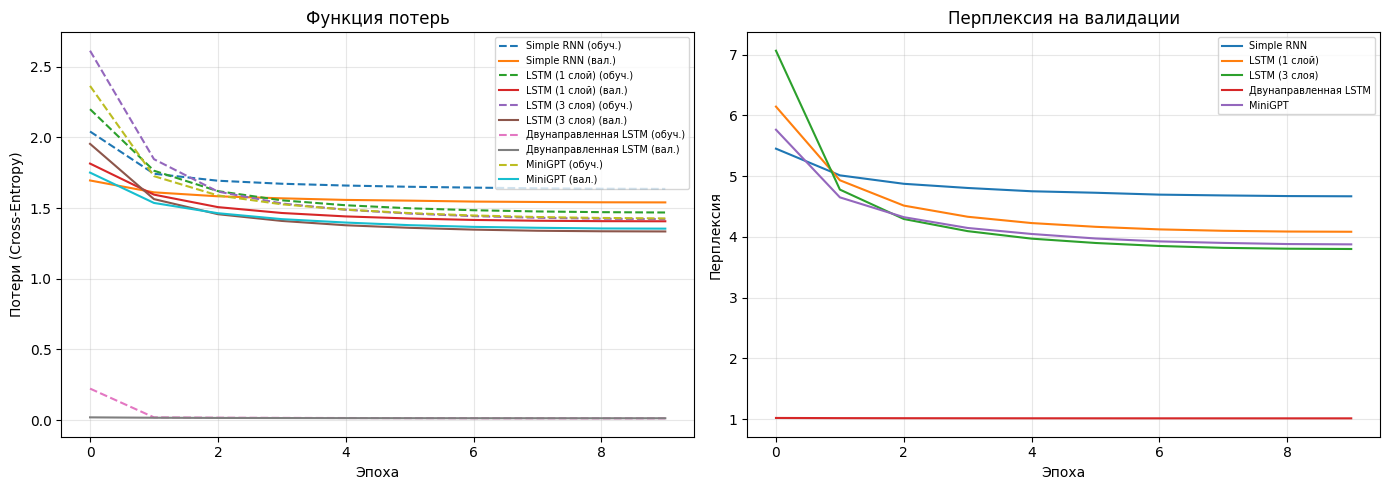

In [10]:
# Визуализация кривых обучения
histories = [history_rnn, history_lstm1, history_lstm3, history_bilstm, history_gpt]
model_names = ["Simple RNN", "LSTM (1 слой)", "LSTM (3 слоя)",
               "Двунаправленная LSTM", "MiniGPT"]

plot_training_history(histories, model_names)

In [11]:
# Таблица результатов
models_list = [model_rnn, model_lstm1, model_lstm3, model_bilstm, model_gpt]
results = []

for model, name, hist in zip(models_list, model_names, histories):
    ppl = compute_perplexity(model.to(device), val_loader, device)
    params = sum(p.numel() for p in model.parameters())
    results.append({
        'name': name,
        'params': params,
        'val_loss': min(hist['val_loss']),
        'perplexity': ppl
    })

print_results_table(results)


Модель                            Параметры  Вал. потери   Перплексия
----------------------------------------------------------------------
Simple RNN                        1,156,411       1.5405         4.67
LSTM (1 слой)                     1,452,859       1.4070         4.08
LSTM (3 слоя)                     2,505,531       1.3350         3.80
Двунаправленная LSTM              4,128,315       0.0134         1.01
MiniGPT                           3,518,139       1.3548         3.88

## 6. Генерация текста

In [12]:
seed_text = "The future of artificial intelligence"
seed_indices = [char_to_idx.get(ch, 0) for ch in seed_text]

print(f"Затравка: '{seed_text}'")
print(f"{'='*60}\n")

for model, name in zip(models_list, model_names):
    model = model.to(device)
    tokens = generate_text(model, seed_indices, vocab_size, idx_to_char,
                           length=300, temperature=0.8, device=device, top_k=0)
    generated = ''.join(tokens)
    print(f"--- {name} ---")
    print(generated)
    print()

Затравка: 'The future of artificial intelligence'

--- Simple RNN ---
The future of artificial intelligence comp2dation of collects and a thems loss on Jeff toged. I took goals anywhere our enarrays is that themed the dreaning to have letservice–wind went. The I would you treat avoiness srip of the same spaces, allow your most impoosirus, do just discovered or a gette

--- LSTM (1 слой) ---
The future of artificial intelligence and additional version, robest class with script.

The Enally which so that’s a supported to visualizing when you get in the exection is taking the search execker tests.

# CDC 1) Renumation that classification far to use ulmonrander, though we have a word is gr

--- LSTM (3 слоя) ---
The future of artificial intelligence, these are familiar to the technology of intelligence. It must replace one feels facing parents surfaces that we do called it. The values were to be the first of AI solutions with the act of ways to understand your new time I had help the doing

In [13]:
# Генерация с разными температурами
print("\n=== Влияние температуры на генерацию (MiniGPT) ===\n")
for temp in [0.3, 0.7, 1.0, 1.5]:
    tokens = generate_text(model_gpt.to(device), seed_indices, vocab_size, idx_to_char,
                           length=200, temperature=temp, device=device, top_k=30)
    generated = ''.join(tokens)
    print(f"Температура = {temp}:")
    print(generated[:200])
    print()


=== Влияние температуры на генерацию (MiniGPT) ===

Температура = 0.3:
The future of artificial intelligence to the product of a single of a sense of a service to be a startup with the project of the protransereractinde aragurooooound actoun oone oooune oure oune oone ol

Температура = 0.7:
The future of artificial intelligence the stream of lazy-concept — the size of new content (the first structure of the control strude ins at obat itingonggrange wine. ale by t. enge g. mene alllll ath

Температура = 1.0:
The future of artificial intelligence, the article distrusting in a background being variable to figure your sales — which differentures ized ints y inct ts ined. fint s — I ds oines t ont ted in t. f

Температура = 1.5:
The future of artificial intelligence of mopic post.

Vue, now with society information from soes itself times anxiety, the ginisty y hingurervedes, nan les)2s, e tisonest aall d ctog — s s.

 laby’s 


## 7. Выводы

### Посимвольная токенизация:
- **Размер словаря** мал (обычно ~100 символов), что упрощает модель
- **Длинные зависимости** — модель должна запоминать контекст на уровне отдельных символов
- **Simple RNN** — быстро обучается, но плохо улавливает длинные зависимости
- **LSTM** — значительно лучше справляется с запоминанием контекста
- **Многослойная LSTM** — даёт улучшение за счёт иерархического представления
- **Двунаправленная LSTM** — помогает для классификации, но для генерации используется только прямое направление
- **MiniGPT** — лучшее качество генерации благодаря механизму внимания